In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
meshki = pd.read_csv("meshki_dataset.csv")
meshki.head()

/tmp/ipykernel_366/3774279246.py:1: DtypeWarning: Columns (4,20,22,23,24,25,27,28,29,30,32,33,34,35,37,38,39,40,42,43,44,73,75,76,77,78,80,81,82,83,85,86,87,110,126,128,129,130,131,133,134,135,179,184,186,187,188,189,191,192,193,232,234,235,236,237,239,240,241,285,287,288,289,290,292,293,294,295,297,298,299,338,340,341,342,343,345,346,347,348,350,351,352,391,393,394,395,396,398,399,400,401,403,404,405,406,408,409,410,411,413,414,415,416,418,419,420,444,446,447,448,449,451,452,453,481,497,499,500,501,502,504,505,506,507,509,510,511,531,550,552,553,554,587,603,605,606,607,637,640,651,653,654,655,656,658,659,660,661,663,664,665,690,692,693,698,703,704,706,707,708,709,711,712,713,714,716,717,718,719,721,722,723,740,741,743,745,746,751,756,757,759,760,761,762,764,765,766,767,769,770,771,793,794,796,798,799,804,809,810,812,813,814,815,817,818,819,846,847,849,851,852,857,862,863,865,866,867,868,870,871,872,899,900,902,904,905,910,915,916,918,919,920,952,953,955,957,958,963,968,969,971,972,973

,alt,audioUrl,caption,childPosts/0/alt,childPosts/0/audioUrl,childPosts/0/caption,childPosts/0/commentsCount,childPosts/0/dimensionsHeight,childPosts/0/dimensionsWidth,childPosts/0/displayUrl,...,taggedUsers/19/is_verified,taggedUsers/19/profile_pic_url,taggedUsers/19/username,timestamp,type,url,videoDuration,videoPlayCount,videoUrl,videoViewCount
0,NaN,https://scontent-atl3-3.cdninstagram.com/o1/v/...,Date nights with your forever person >>> @alic...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2026-01-26T05:10:12.000Z,Video,https://www.instagram.com/p/DT9irtGkT1g/,26.900,191625.0,https://scontent-atl3-2.cdninstagram.com/o1/v/...,41840.0
1,"Photo by MESHKI on January 24, 2026. May be an...",NaN,Our SOFIE dress for your galentines plans 💐 @m...,"Photo by MESHKI on January 24, 2026. May be an...",NaN,NaN,0.0,1439.0,1080.0,https://scontent-lga3-2.cdninstagram.com/v/t51...,...,NaN,NaN,NaN,2026-01-24T09:29:13.000Z,Sidecar,https://www.instagram.com/p/DT42_x4kV_G/,NaN,NaN,NaN,NaN
2,"Photo by MESHKI on January 13, 2026. May be an...",NaN,"Iran, the land of poetry and ancient beauty. A...","Photo by MESHKI on January 13, 2026. May be an...",NaN,NaN,0.0,1346.0,1080.0,https://scontent-mia3-2.cdninstagram.com/v/t51...,...,NaN,NaN,NaN,2026-01-13T10:30:48.000Z,Sidecar,https://www.instagram.com/p/DTcpTH-EanR/,NaN,NaN,NaN,NaN
3,NaN,https://scontent-lax3-1.cdninstagram.com/o1/v/...,Our top pick for valentines: ALESSANDRA dress 🤍,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2026-01-25T22:52:11.000Z,Video,https://www.instagram.com/p/DT83n8kku15/,7.533,102032.0,https://scontent-lax7-1.cdninstagram.com/o1/v/...,13190.0
4,NaN,https://scontent-ord5-3.cdninstagram.com/o1/v/...,Save this for galentines inspo 💖,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2026-01-23T11:34:26.000Z,Video,https://www.instagram.com/p/DT2gdaFkTfq/,16.370,158107.0,https://scontent-ord5-3.cdninstagram.com/o1/v/...,0.0


In [3]:
selected_column = ['commentsCount', 'likesCount', 'timestamp', 'type', 'videoPlayCount', 'videoViewCount', 'videoDuration']

In [4]:
meshki = meshki[selected_column]
meshki.head()

,commentsCount,likesCount,timestamp,type,videoPlayCount,videoViewCount,videoDuration
0,59,7721,2026-01-26T05:10:12.000Z,Video,191625.0,41840.0,26.900
1,18,1833,2026-01-24T09:29:13.000Z,Sidecar,NaN,NaN,NaN
2,1495,22465,2026-01-13T10:30:48.000Z,Sidecar,NaN,NaN,NaN
3,4,408,2026-01-25T22:52:11.000Z,Video,102032.0,13190.0,7.533
4,13,4042,2026-01-23T11:34:26.000Z,Video,158107.0,0.0,16.370


In [5]:
unique_categ = meshki['type'].value_counts()
unique_categ

,count
type,
Video,1006
Sidecar,579
Image,18


Sidecar post is essentially just a carousel of multiple images and are thus labelled as Image combined with other single images moving forward.

In [6]:
meshki['type'] = meshki['type'].replace({
    'Sidecar': 'image',
    'Image': 'image',
    'Video': 'video'

})

In [7]:
meshki.head()

,commentsCount,likesCount,timestamp,type,videoPlayCount,videoViewCount,videoDuration
0,59,7721,2026-01-26T05:10:12.000Z,video,191625.0,41840.0,26.900
1,18,1833,2026-01-24T09:29:13.000Z,image,NaN,NaN,NaN
2,1495,22465,2026-01-13T10:30:48.000Z,image,NaN,NaN,NaN
3,4,408,2026-01-25T22:52:11.000Z,video,102032.0,13190.0,7.533
4,13,4042,2026-01-23T11:34:26.000Z,video,158107.0,0.0,16.370


In [8]:
meshki['videoEngagementRate'] = (meshki['likesCount'] + meshki['commentsCount']*2) / meshki['videoViewCount'] * 100
meshki.head()


,commentsCount,likesCount,timestamp,type,videoPlayCount,videoViewCount,videoDuration,videoEngagementRate
0,59,7721,2026-01-26T05:10:12.000Z,video,191625.0,41840.0,26.900,18.735660
1,18,1833,2026-01-24T09:29:13.000Z,image,NaN,NaN,NaN,NaN
2,1495,22465,2026-01-13T10:30:48.000Z,image,NaN,NaN,NaN,NaN
3,4,408,2026-01-25T22:52:11.000Z,video,102032.0,13190.0,7.533,3.153904
4,13,4042,2026-01-23T11:34:26.000Z,video,158107.0,0.0,16.370,inf


In [9]:
#checking if there are any NaNs in videoEngagementRate problem

nan_count = (
    meshki.loc[meshki['type'] == 'video', 'videoEngagementRate']
    .isna()
    .sum()
)

In [10]:
meshki['weighted_engagement'] = (meshki['likesCount'] + meshki['commentsCount']*2)

In [12]:
WINDOW = 25
image_mask = meshki['type'] == 'image'

def rolling_zscore_min(series, window, min_periods=2):
    mean = series.rolling(window = window, min_periods = min_periods).mean()
    std = series.rolling(window = window, min_periods = min_periods).std()
    return (series - mean) / std

meshki['weighted_engagement_rate'] = np.nan
meshki.loc[image_mask, 'weighted_engagement_rate'] = rolling_zscore_min(
    meshki.loc[image_mask, 'weighted_engagement'],
    window=WINDOW,
    min_periods=5
)

In [13]:
# NaNs if weighted_engagement itself has missing values

meshki.loc[image_mask, 'weighted_engagement_rate'].isna().sum()


np.int64(4)

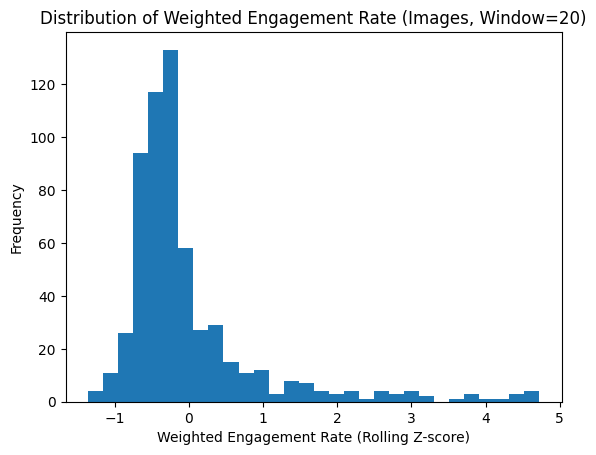

In [14]:
dist_data = meshki.loc[
    (meshki['type'] == 'image') &
    (~meshki['weighted_engagement_rate'].isna()),
    'weighted_engagement_rate'
]

plt.figure()
plt.hist(dist_data, bins=30)
plt.xlabel('Weighted Engagement Rate (Rolling Z-score)')
plt.ylabel('Frequency')
plt.title('Distribution of Weighted Engagement Rate (Images, Window=20)')
plt.show()

In [15]:
dist_data.describe()

,weighted_engagement_rate
count,593.000000
mean,-0.004437
std,0.976972
min,-1.359593
25%,-0.511406
50%,-0.289473
75%,0.062243
max,4.722530


In [16]:
meshki = meshki[meshki['videoViewCount'] != 0]

(meshki['videoViewCount'] == '0.0').sum()

np.int64(0)

## Separating datasets for video and images

In [17]:
meshki_video = meshki[meshki['type'] == 'video']
meshki_image = meshki[meshki['type'] == 'image']

## Running first model: Prophet

In [18]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics


In [19]:
meshki['timestamp'] = (
    pd.to_datetime(meshki['timestamp'], utc=True)
      .dt.tz_convert('Australia/Sydney')
)

In [20]:
# adding holiday seasons

holidays = pd.DataFrame([
    # --- Black Friday ---
    {
        'holiday': 'black_friday',
        'ds': '2024-11-29',
        'lower_window': -5,
        'upper_window': 2
    },
    {
        'holiday': 'black_friday',
        'ds': '2025-11-28',
        'lower_window': -5,
        'upper_window': 2
    },

    # --- Christmas ---
    {
        'holiday': 'christmas',
        'ds': '2024-12-25',
        'lower_window': -10,
        'upper_window': 5
    },
    {
        'holiday': 'christmas',
        'ds': '2025-12-25',
        'lower_window': -10,
        'upper_window': 5
    },

    # --- Valentine’s Day ---
    {
        'holiday': 'valentines_day',
        'ds': '2025-02-14',
        'lower_window': -5,
        'upper_window': 1
    },

    # --- End of Summer (fashion seasonality, not a fixed holiday) ---
    {
        'holiday': 'end_of_summer',
        'ds': '2024-08-31',
        'lower_window': -14,
        'upper_window': 7
    },
    {
        'holiday': 'end_of_summer',
        'ds': '2025-08-31',
        'lower_window': -14,
        'upper_window': 7
    },

    # --- Winter Season kickoff ---
    {
        'holiday': 'winter_season',
        'ds': '2024-11-01',
        'lower_window': 0,
        'upper_window': 30
    },
    {
        'holiday': 'winter_season',
        'ds': '2025-11-01',
        'lower_window': 0,
        'upper_window': 30
    },
])

# Ensure datetime
holidays['ds'] = pd.to_datetime(holidays['ds'])

In [21]:
video_df = meshki_video[['timestamp', 'videoEngagementRate']].dropna()

video_prophet = (
    meshki_video[['timestamp', 'videoEngagementRate']]
    .dropna()
    .rename(columns={'timestamp': 'ds', 'videoEngagementRate': 'y'})
)

# Strip timezone AFTER converting
video_prophet['ds'] = (
    pd.to_datetime(video_prophet['ds'])
      .dt.tz_localize(None)
)

m_video = Prophet(
    changepoint_prior_scale=0.06,  # Smaller values make trends smoother. Larger values detect more shifts.
    seasonality_prior_scale=10,    # Adjusts how strongly seasonal patterns are fitted
    holidays=holidays,
    seasonality_mode='multiplicative',
    weekly_seasonality=True,
    yearly_seasonality=True
)

m_video.fit(video_prophet)


In [22]:
future_video = m_video.make_future_dataframe(periods=30, freq='D')
future_video['ds'] = future_video['ds'].dt.tz_localize(None)


forecast_video = m_video.predict(future_video)


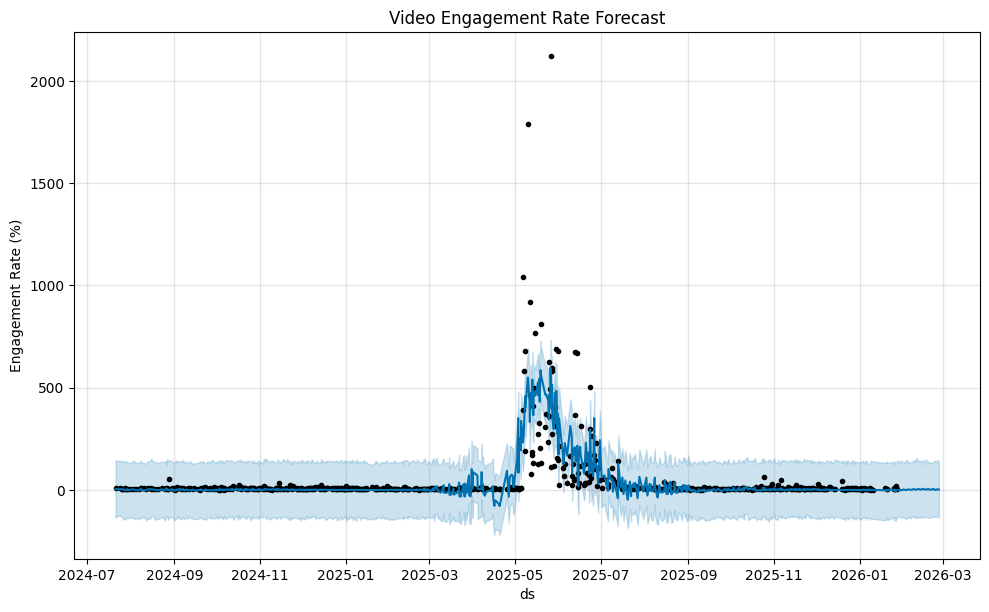

In [23]:
fig1 = m_video.plot(forecast_video)
plt.title('Video Engagement Rate Forecast')
plt.ylabel('Engagement Rate (%)')
plt.show()

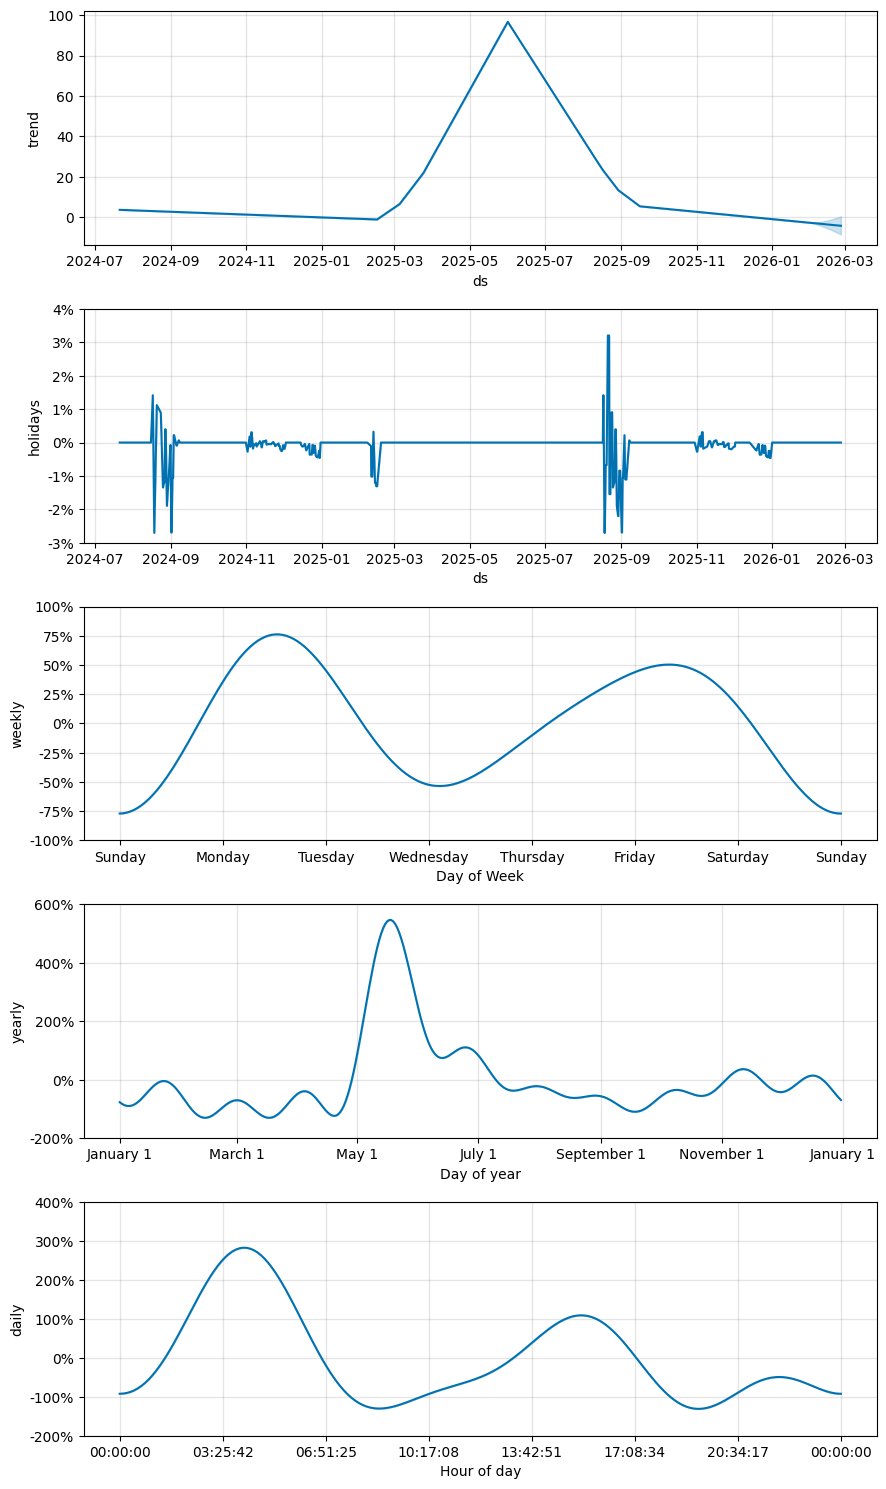

In [24]:
fig2 = m_video.plot_components(forecast_video)
plt.show()

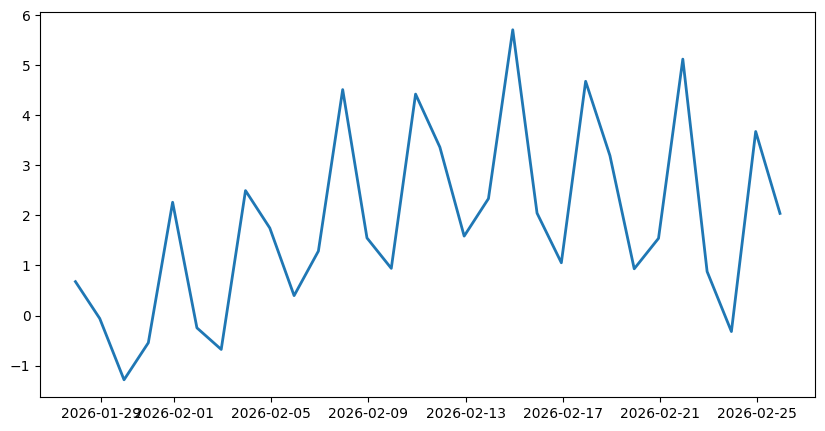

In [25]:
last_date = video_prophet['ds'].max()

forecast_only = forecast_video[forecast_video['ds'] > last_date]
plt.figure(figsize=(10, 5))
plt.plot(
    forecast_only['ds'],
    forecast_only['yhat'],
    label='Forecast',
    linewidth=2
)

## Cross‑validation (to evaluate Prophet, for later comparison)

In [26]:
df_cv_video = cross_validation(
    m_video,
    initial='365 days',   # first training window
    period='30 days',     # step between cutoffs
    horizon='30 days'     # forecast horizon
)
video_perf = performance_metrics(df_cv_video)
video_perf[['horizon', 'mape', 'rmse', 'mae']].head()

INFO:prophet:Making 6 forecasts with cutoffs between 2025-07-30 22:35:29 and 2025-12-27 22:35:29


  0%|          | 0/6 [00:00<?, ?it/s]

,horizon,mape,rmse,mae
0,2 days 12:33:55,6.253387,40.384225,27.043603
1,2 days 23:26:13,5.904017,35.333636,23.096918
2,3 days 00:27:27,6.236628,45.853249,28.334933
3,3 days 01:27:35,6.256918,45.856622,28.345587
4,3 days 06:25:02,6.725897,48.136378,30.199025


## ARIMA/SARIMA

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
#unit root test to test stationarity

def adf_test(series, name='series'):
    """Print ADF test result to decide if differencing is needed."""
    result = adfuller(series.dropna())
    print(f"\nADF Test for {name}")
    print(f"  ADF statistic: {result[0]:.3f}")
    print(f"  p-value:       {result[1]:.4f}")
    print("  → Stationary" if result[1] < 0.05 else "  → Non‑stationary")


In [ ]:
# differencing to make this stationary

def make_stationary(series, name='series'):
    """Run ADF; if non-stationary, difference once and test again."""
    adf_test(series, name)
    if adfuller(series.dropna())[1] < 0.05:
        # Already stationary
        return series, 0
    # 1st difference
    diff1 = series.diff()
    adf_test(diff1.dropna(), name + " (1st diff)")
    if adfuller(diff1.dropna())[1] < 0.05:
        return diff1, 1
    # If still non‑stationary, you could diff again, but usually d<=1 is enough
    return diff1, 1

In [ ]:
# Ensure datetime & sort
meshki_video['timestamp'] = pd.to_datetime(meshki_video['timestamp'])
meshki_video = meshki_video.sort_values('timestamp')

# Daily mean engagement rate
video_daily = (
    meshki_video
    .set_index('timestamp')['videoEngagementRate']
    .resample('D')
    .mean()
    .dropna()
)

video_daily.name = 'video_engagement'

/tmp/ipython-input-2131197189.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meshki_video['timestamp'] = pd.to_datetime(meshki_video['timestamp'])


In [ ]:
video_stationary, d_video = make_stationary(video_daily, 'Video Engagement')
print(f"\nUsing d = {d_video} for videos")


ADF Test for Video Engagement
  ADF statistic: -3.043
  p-value:       0.0311
  → Stationary

Using d = 0 for videos


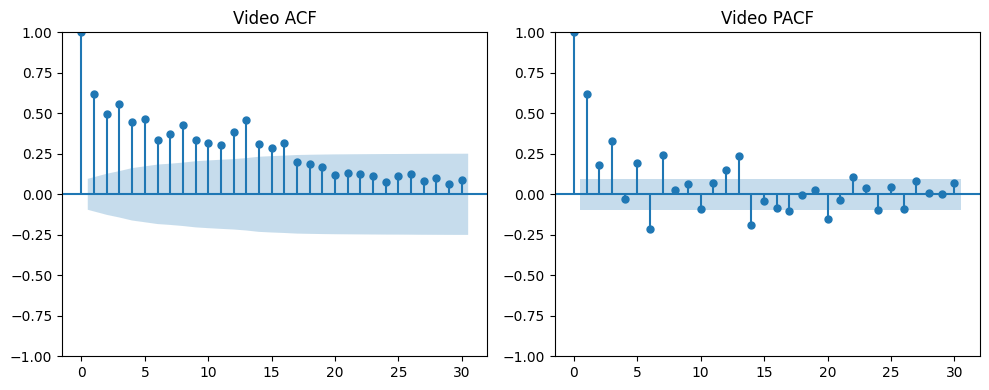

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_acf(video_stationary.dropna(), lags=30, ax=axes[0])
axes[0].set_title('Video ACF')
plot_pacf(video_stationary.dropna(), lags=30, ax=axes[1])
axes[1].set_title('Video PACF')
plt.tight_layout()
plt.show()

Although the ACF shows slow decay, the ADF test rejects a unit root, indicating the series is stationary but highly persistent; the PACF cutoff at lag 2 suggests modeling this persistence with AR terms rather than differencing.”

In [ ]:
split_idx = int(len(video_daily) * 0.8)
train_video = video_daily.iloc[:split_idx]
test_video  = video_daily.iloc[split_idx:]

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

order_video = (2, d_video, 2)
seasonal_order_video = (0, 0, 0, 0)   # weekly seasonality

model_video = SARIMAX(
    train_video,
    order=order_video,
    seasonal_order=seasonal_order_video,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_video = model_video.fit(disp=False)
print(results_video.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:       video_engagement   No. Observations:                  336
Model:               SARIMAX(2, 0, 2)   Log Likelihood               -2038.126
Date:                Sun, 01 Feb 2026   AIC                           4086.252
Time:                        01:12:21   BIC                           4105.292
Sample:                             0   HQIC                          4093.844
                                - 336                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3885      0.049      7.862      0.000       0.292       0.485
ar.L2          0.5450      0.044     12.418      0.000       0.459       0.631
ma.L1          0.1992      0.044      4.523      0.0

#Some conclusions:

1. A non‑seasonal ARIMA(2,0,2) captures short‑term dependence in daily video engagement (lags 1 and 2 are significant).

2. Diagnostics show no strong leftover autocorrelation, but residuals are highly heteroskedastic and non‑normal due to rare large spikes.

3. This model is suitable for forecasting baseline / “normal” engagement, but cannot reliably predict viral spikes, which appear as genuine shocks.

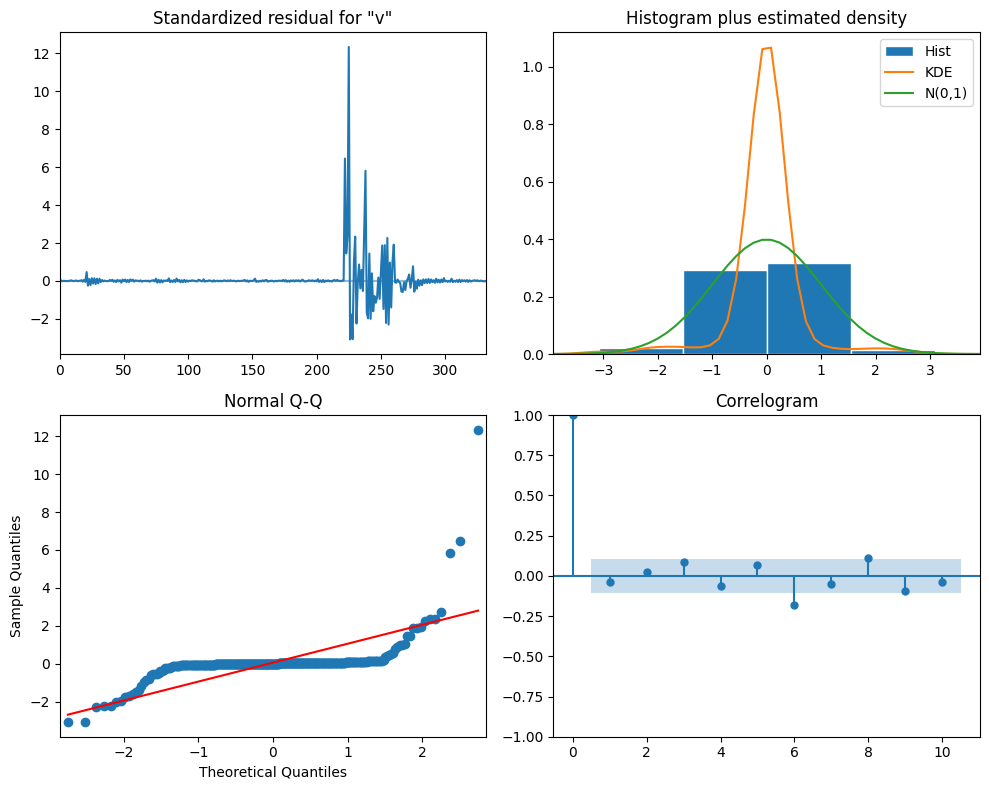

In [ ]:
results_video.plot_diagnostics(figsize=(10, 8))
plt.tight_layout()
plt.show()

# Interpretations for graphs above:

1. No strong residual autocorrelation → ARIMA(2,0,2) captures the main temporal structure.

2. Residuals are very non‑normal and heteroskedastic because of one or more huge engagement bursts.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


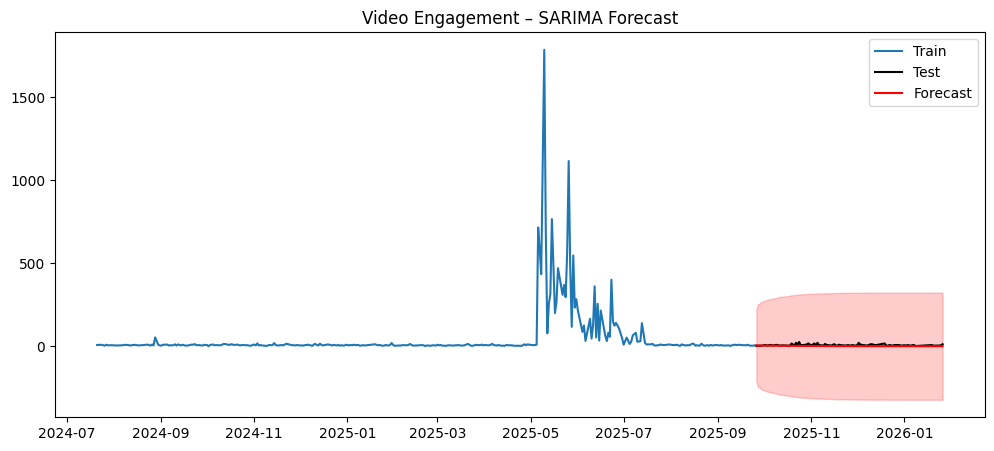

Video SARIMA – MAE: 6.02, RMSE: 7.68


In [ ]:
# Forecast same length as test
n_test = len(test_video)
pred_video = results_video.get_forecast(steps=n_test)
pred_mean_video = pred_video.predicted_mean
pred_ci_video = pred_video.conf_int()

# Align index
pred_mean_video.index = test_video.index
pred_ci_video.index = test_video.index

# Plot
plt.figure(figsize=(12, 5))
plt.plot(train_video.index, train_video, label='Train')
plt.plot(test_video.index, test_video, label='Test', color='black')
plt.plot(pred_mean_video.index, pred_mean_video, label='Forecast', color='red')
plt.fill_between(pred_ci_video.index,
                 pred_ci_video.iloc[:, 0],
                 pred_ci_video.iloc[:, 1],
                 color='red', alpha=0.2)
plt.title('Video Engagement – SARIMA Forecast')
plt.legend()
plt.show()

# Error metrics
mae_v = mean_absolute_error(test_video, pred_mean_video)
rmse_v = np.sqrt(mean_squared_error(test_video, pred_mean_video))
print(f"Video SARIMA – MAE: {mae_v:.2f}, RMSE: {rmse_v:.2f}")


In [ ]:
# Refit on full series for production forecast
final_model_video = SARIMAX(
    video_daily,
    order=order_video,
    seasonal_order=seasonal_order_video,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

steps_ahead = 30
future_forecast_video = final_model_video.get_forecast(steps=steps_ahead)
future_mean_v = future_forecast_video.predicted_mean
future_ci_v = future_forecast_video.conf_int()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## Log transformation

In [27]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# --- Prepare daily series ---
meshki_video['timestamp'] = pd.to_datetime(meshki_video['timestamp'])
meshki_video = meshki_video.sort_values('timestamp')

video_daily = (
    meshki_video
    .set_index('timestamp')['videoEngagementRate']
    .resample('D')
    .mean()
    .dropna()
)

# Avoid log(0): add small constant if needed
eps = 1e-6
video_daily_log = np.log(video_daily + eps)
video_daily_log.name = 'video_engagement_log'


/tmp/ipykernel_366/3112901103.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meshki_video['timestamp'] = pd.to_datetime(meshki_video['timestamp'])


In [28]:
def adf_test(series, name='series'):
    result = adfuller(series.dropna())
    print(f"\nADF for {name}: statistic={result[0]:.3f}, p={result[1]:.4f}")

adf_test(video_daily_log, 'Video log')

# If p > 0.05, difference once
video_log_diff = video_daily_log.diff().dropna()
adf_test(video_log_diff, 'Video log diff')

# Choose d depending on which one is stationary
d_video_log = 1 if adfuller(video_daily_log.dropna())[1] >= 0.05 else 0
series_v = video_daily_log if d_video_log == 0 else video_log_diff
print(f"Using d={d_video_log} for log-video ARIMA")



ADF for Video log: statistic=-3.032, p=0.0320

ADF for Video log diff: statistic=-10.838, p=0.0000
Using d=0 for log-video ARIMA


In [29]:
split_idx = int(len(series_v) * 0.8)
train_v = series_v.iloc[:split_idx]
test_v  = series_v.iloc[split_idx:]


In [30]:
order_v = (2, d_video_log, 2)
seasonal_order_v = (0, 0, 0, 0)

model_v = SARIMAX(
    train_v,
    order=order_v,
    seasonal_order=seasonal_order_v,
    enforce_stationarity=False,
    enforce_invertibility=False
)
res_v = model_v.fit(disp=False)
print(res_v.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                SARIMAX Results                                 
Dep. Variable:     video_engagement_log   No. Observations:                  336
Model:                 SARIMAX(2, 0, 2)   Log Likelihood                -364.232
Date:                  Tue, 10 Mar 2026   AIC                            738.464
Time:                          06:57:25   BIC                            757.505
Sample:                               0   HQIC                           746.057
                                  - 336                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9517      0.823      1.157      0.247      -0.660       2.564
ar.L2          0.0430      0.818      0.053      0.958      -1.560       1.646
ma.L1         -0.5386      0.820    

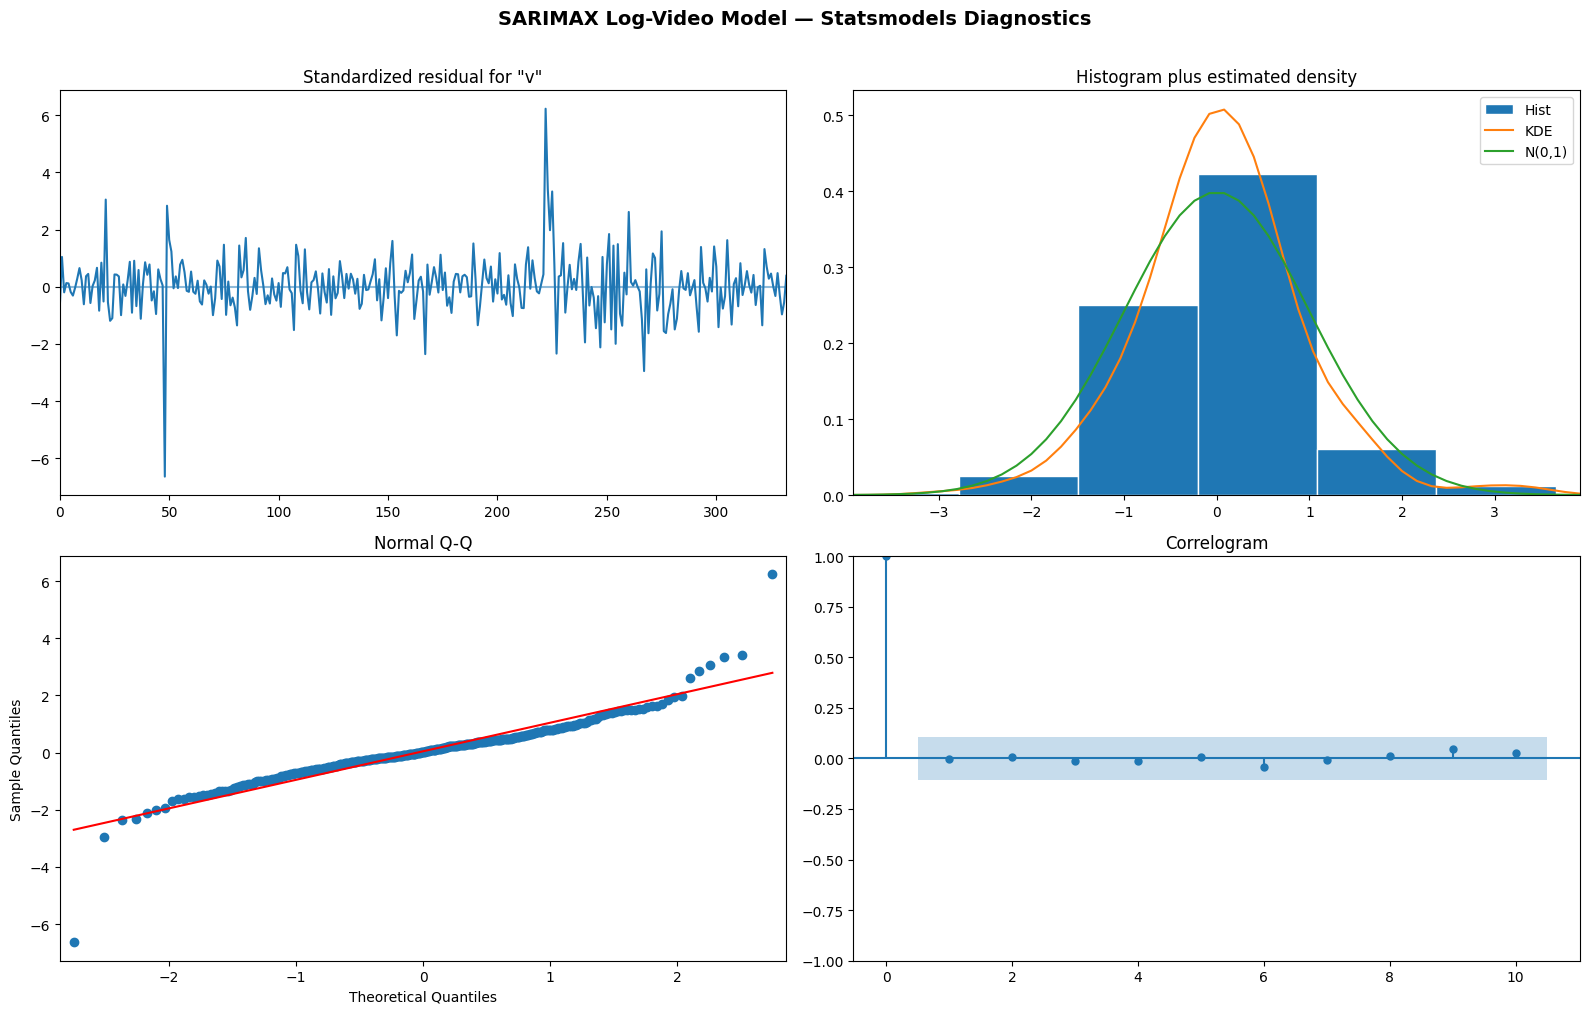

In [31]:
fig_diag = res_v.plot_diagnostics(figsize=(16, 10))
fig_diag.suptitle('SARIMAX Log-Video Model — Statsmodels Diagnostics',
                   fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


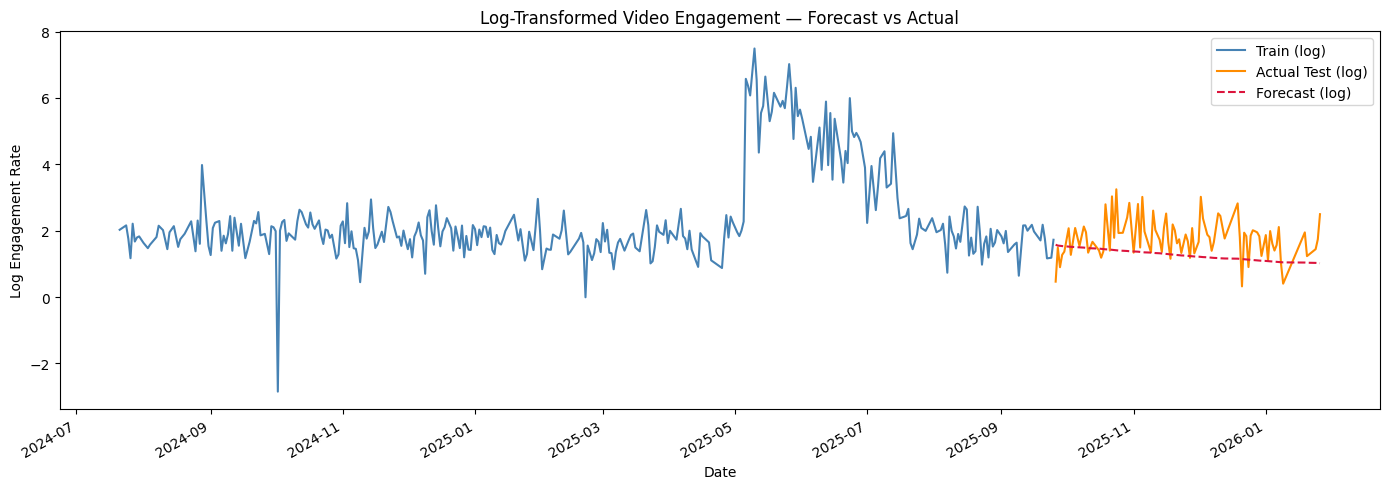

In [33]:
# ── 2. Forecast vs Actual (log scale) ────────────────────────────────────────
forecast_log = res_v.forecast(steps=len(test_v))
forecast_log.index = test_v.index

fig, ax = plt.subplots(figsize=(14, 5))
train_v.plot(ax=ax, label='Train (log)', color='steelblue')
test_v.plot(ax=ax, label='Actual Test (log)', color='darkorange')
forecast_log.plot(ax=ax, label='Forecast (log)', color='crimson', linestyle='--')
ax.set_title('Log-Transformed Video Engagement — Forecast vs Actual')
ax.set_xlabel('Date')
ax.set_ylabel('Log Engagement Rate')
ax.legend()
plt.tight_layout()
plt.show()

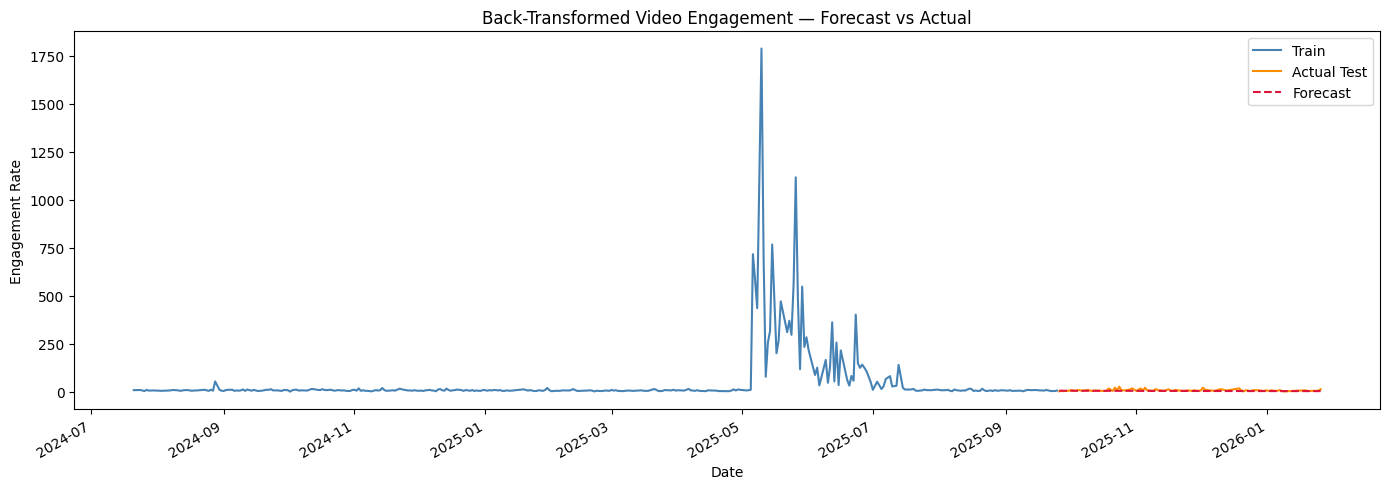

In [34]:
eps = 1e-6
actual_orig    = np.exp(test_v) - eps
forecast_orig  = np.exp(forecast_log) - eps
train_orig     = np.exp(train_v) - eps

fig, ax = plt.subplots(figsize=(14, 5))
train_orig.plot(ax=ax, label='Train', color='steelblue')
actual_orig.plot(ax=ax, label='Actual Test', color='darkorange')
forecast_orig.plot(ax=ax, label='Forecast', color='crimson', linestyle='--')
ax.set_title('Back-Transformed Video Engagement — Forecast vs Actual')
ax.set_xlabel('Date')
ax.set_ylabel('Engagement Rate')
ax.legend()
plt.tight_layout()
plt.show()